Columns in dataset:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses']

Target Column: expenses


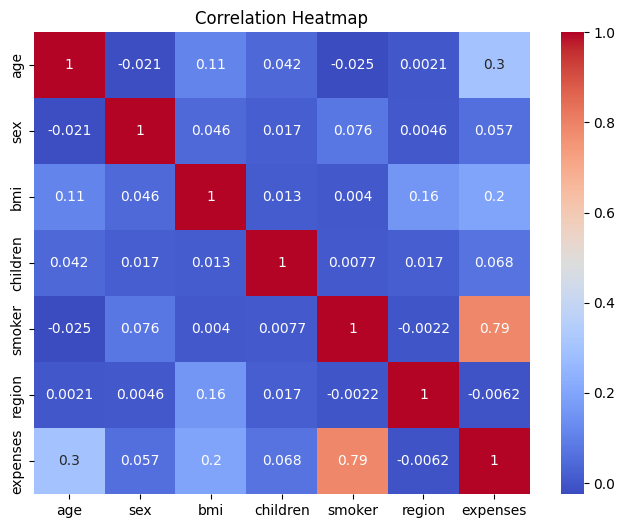


Mean Absolute Error (MAE): 4186.940106317013
Root Mean Squared Error (RMSE): 5799.920265829357


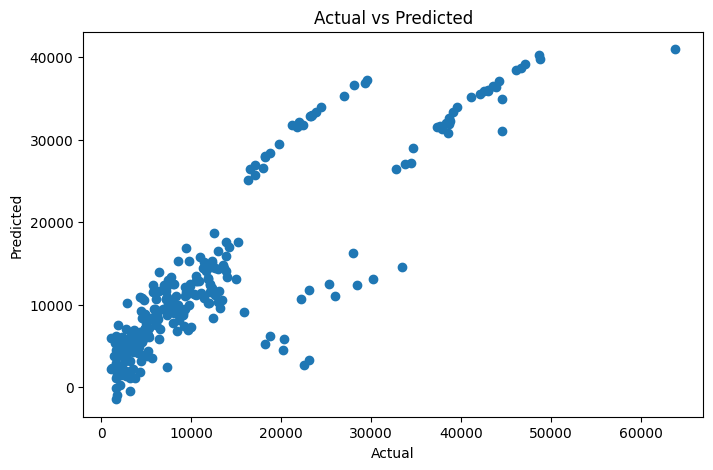

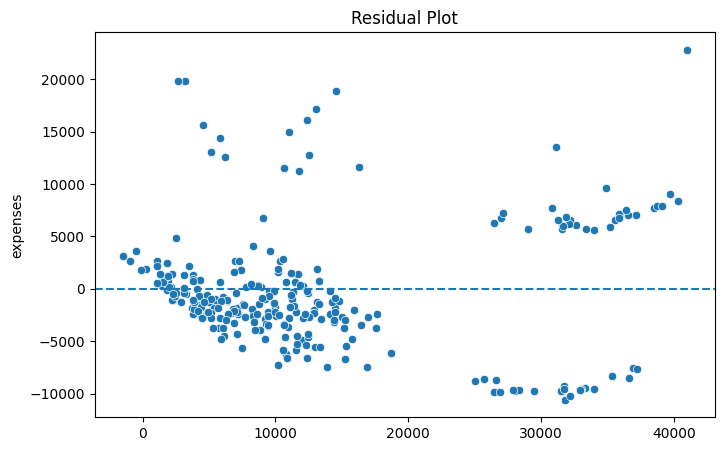


Feature Importance:
    Feature   Coefficient
4    smoker  23646.927259
3  children    425.463175
2       bmi    335.939380
0       age    257.038298
1       sex    -18.704810
5    region   -271.222476


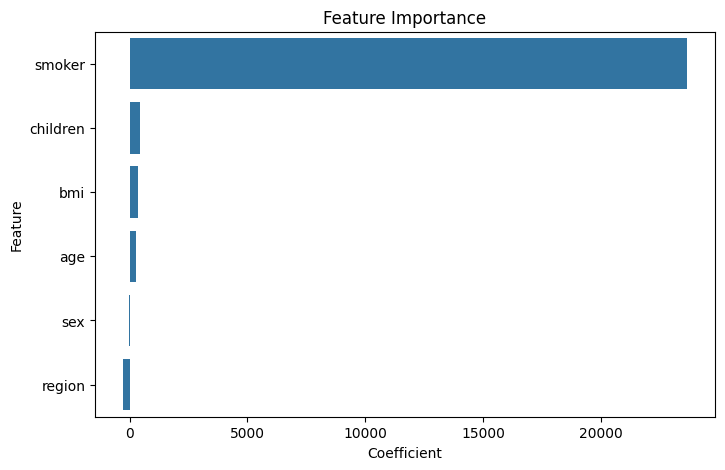

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
df = pd.read_csv("/content/insurance.csv")

print("Columns in dataset:")
print(df.columns.tolist())

# Find target column automatically
possible_targets = [
    'charges',
    'expenses',
    'insurance_charges',
    'medical_cost',
    'claim_amount'
]

target = None

for col in possible_targets:
    if col in df.columns:
        target = col
        break

if target is None:
    print("\nCould not find target column.")
    print("Available columns:", df.columns.tolist())
    raise ValueError("Update target column name according to your dataset.")

print("\nTarget Column:", target)

# Encode categorical columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop(target, axis=1)
y = df[target]

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nMean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

# Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, linestyle='--')
plt.title("Residual Plot")
plt.show()

# Feature Importance
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("\nFeature Importance:")
print(coef_df)

plt.figure(figsize=(8,5))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)
plt.title("Feature Importance")
plt.show()